In [7]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df= pd.read_csv('disasters.csv')
df.head()

,Disaster_ID,Disaster_Type,Location,Magnitude,Date,Fatalities,Economic_Loss($)
0,1,Wildfire,Brazil,6.267393,2024-01-01 00:00:00,9706,6.509790e+08
1,2,Hurricane,Indonesia,6.649358,2024-01-01 01:00:00,2233,5.538357e+08
2,3,Tornado,China,9.724366,2024-01-01 02:00:00,478,6.910998e+07
3,4,Flood,India,1.702505,2024-01-01 03:00:00,2867,8.474880e+08
4,5,Flood,Brazil,7.917748,2024-01-01 04:00:00,776,6.449297e+08


In [9]:
#Misssing Null Values
print("Missing null Values")
df.isnull().sum()

Missing null Values


,0
Disaster_ID,0
Disaster_Type,0
Location,0
Magnitude,0
Date,0
Fatalities,0
Economic_Loss($),0


CONVERT TO DATE TIME


In [10]:
#spilt the data
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df.drop('Date', axis=1, inplace=True)

AFTER SPILT VIEW THE TABLE

In [11]:
print("The First 5 rows")
df.head(5)

The First 5 rows


,Disaster_ID,Disaster_Type,Location,Magnitude,Fatalities,Economic_Loss($),Year,Month
0,1,Wildfire,Brazil,6.267393,9706,6.509790e+08,2024,1
1,2,Hurricane,Indonesia,6.649358,2233,5.538357e+08,2024,1
2,3,Tornado,China,9.724366,478,6.910998e+07,2024,1
3,4,Flood,India,1.702505,2867,8.474880e+08,2024,1
4,5,Flood,Brazil,7.917748,776,6.449297e+08,2024,1


UNIQUE VALUES


In [12]:
print(df['Disaster_Type'].unique())
print(df['Location'].unique())
print(df['Year'].unique())

['Wildfire' 'Hurricane' 'Tornado' 'Flood' 'Earthquake']
['Brazil' 'Indonesia' 'China' 'India' 'USA' 'Japan']
[2024 2025]


DATA VISUALATION


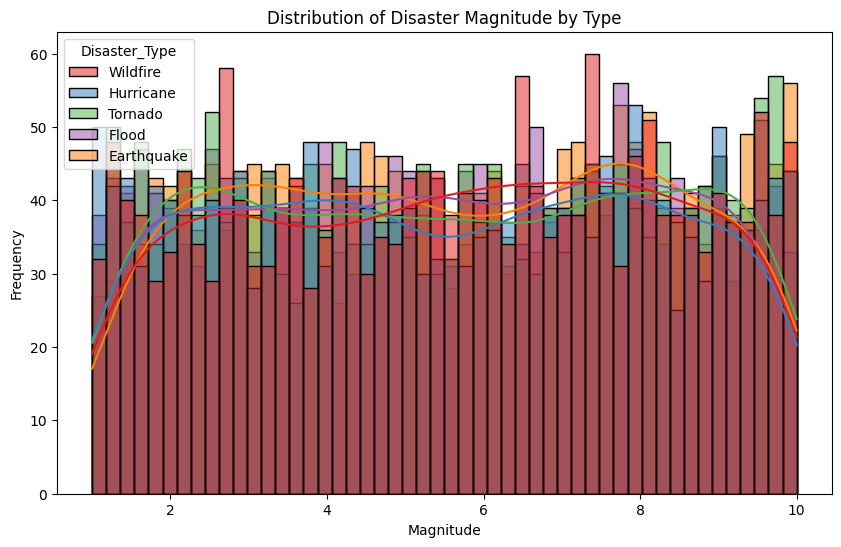

In [13]:
# 1. Distribution of Magnitude
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Magnitude', kde=True, bins=50, hue='Disaster_Type', palette="Set1")
plt.title('Distribution of Disaster Magnitude by Type')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.show()

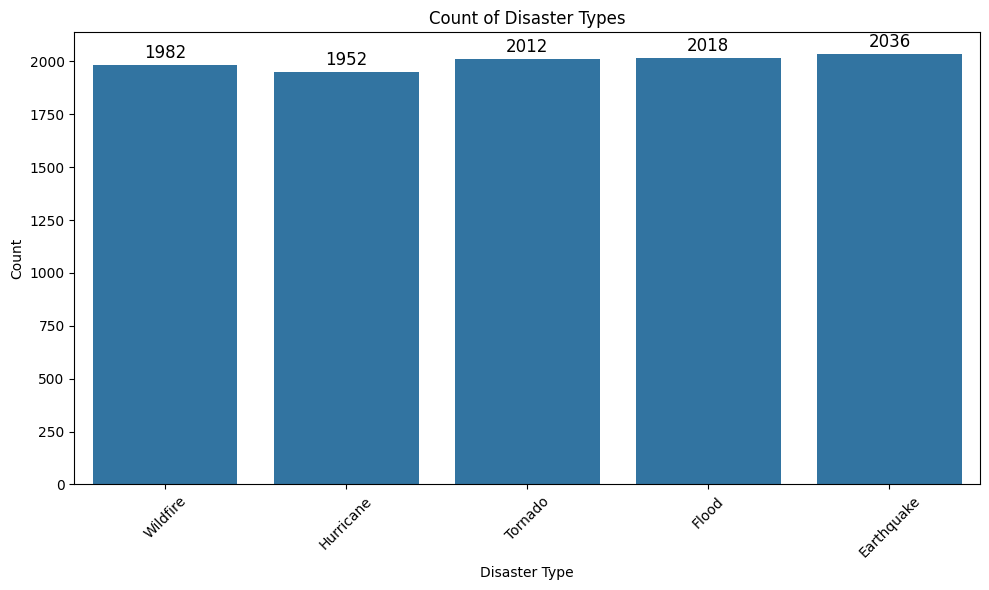

In [14]:
# 2. Count of Disaster Types
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Disaster_Type', )
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black',
                xytext=(0, 5), textcoords='offset points')
plt.title('Count of Disaster Types')
plt.xlabel('Disaster Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

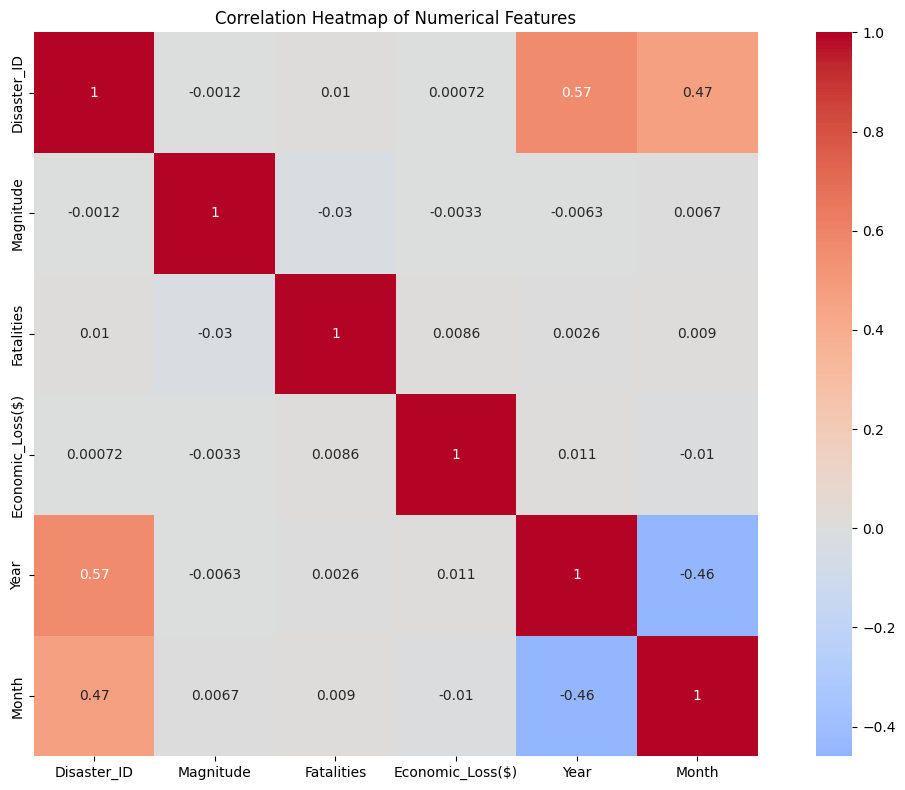

In [15]:
# 4. Correlation Heatmap
plt.figure(figsize=(12, 8))
# Create correlation matrix for numerical columns only
numerical_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numerical_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

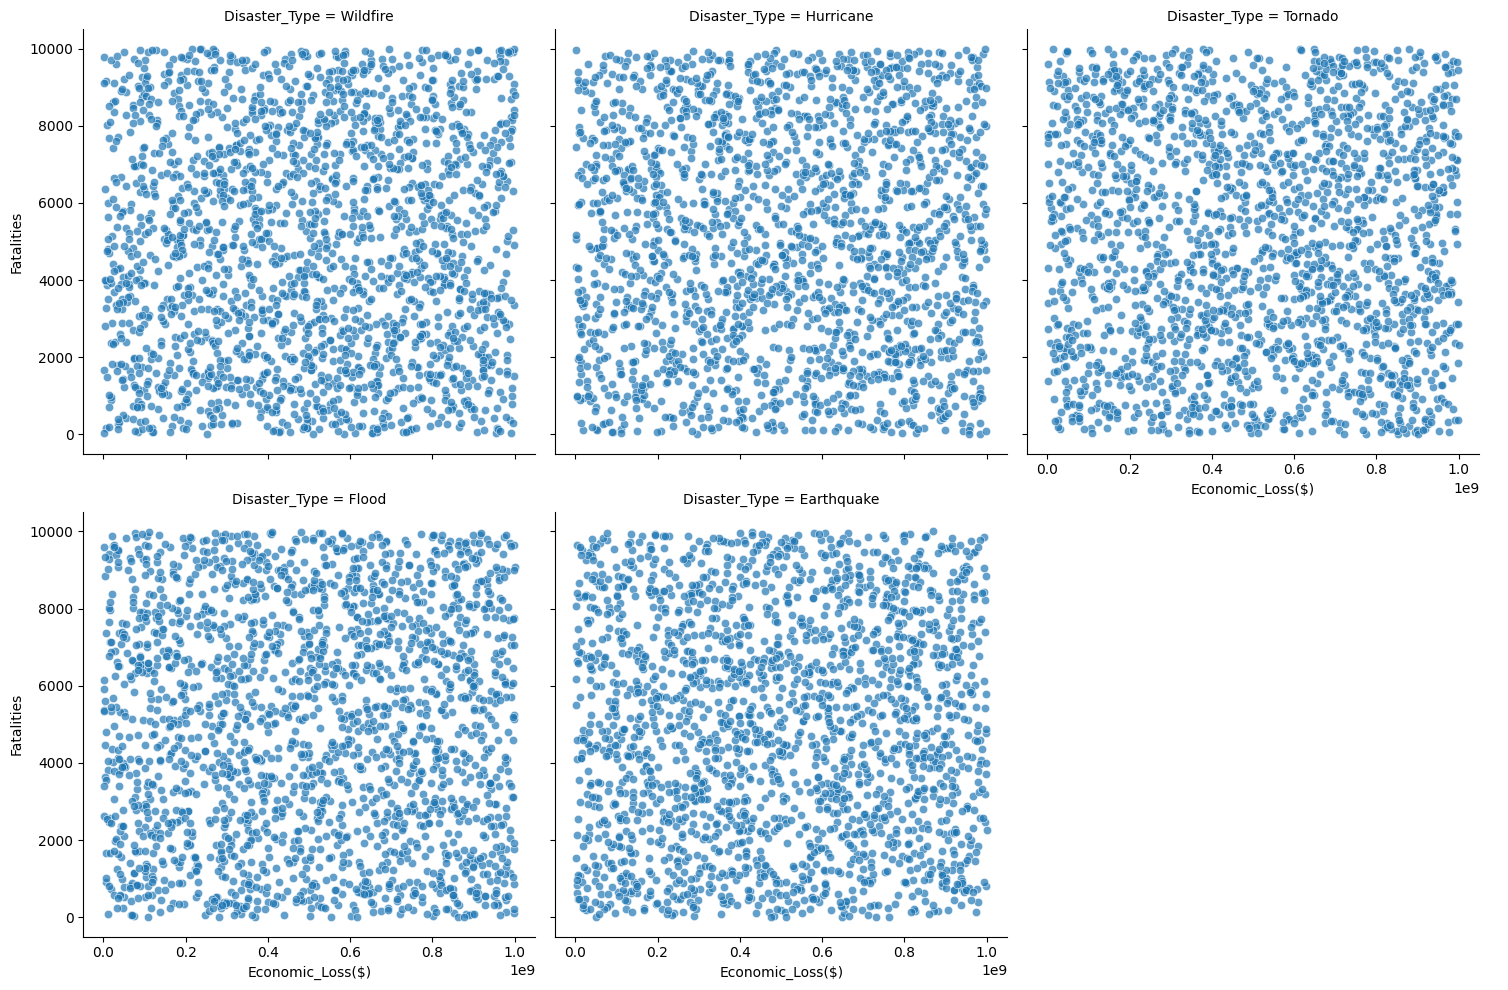

In [16]:
# 6. FacetGrid for detailed analysis
g = sns.FacetGrid(df, col='Disaster_Type', height=5, col_wrap=3)
g.map(sns.scatterplot, 'Economic_Loss($)', 'Fatalities', alpha=0.7)
g.add_legend()
plt.show()

In [17]:
feature_columns = ['Magnitude', 'Economic_Loss($)','Fatalities']
target_column = 'Disaster_Type'

X = df[feature_columns]
y = df[target_column]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

df = df.dropna(subset=feature_columns + [target_column])

Features shape: (10000, 3)
Target shape: (10000,)


Model Training


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

Label Encoded

In [19]:
le = LabelEncoder()
y = le.fit_transform(y)

In [20]:
print(np.unique(y))

[0 1 2 3 4]


Model Building

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

model evaluating


In [22]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [23]:
print(accuracy)

0.194


In [24]:


print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))



Classification Report:
               precision    recall  f1-score   support

  Earthquake       0.19      0.21      0.20       388
       Flood       0.18      0.18      0.18       403
   Hurricane       0.20      0.18      0.19       399
     Tornado       0.18      0.18      0.18       407
    Wildfire       0.21      0.21      0.21       403

    accuracy                           0.19      2000
   macro avg       0.19      0.19      0.19      2000
weighted avg       0.19      0.19      0.19      2000



In [25]:
acc = accuracy_score(y_test, model.predict(X_test))
print(acc)

0.194


In [26]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 98.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 123.2 MB/s eta 0:00:00


In [27]:
import streamlit as st

In [28]:
! wget -q -O - ipv4.icanhazip.com

34.124.246.58


In [29]:
%%writefile app.py

import streamlit as st
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import joblib

# Load your saved model
# model = joblib.load("/content/disaster_model.pkl")

df = pd.read_csv('disasters.csv')

feature_columns = ['Magnitude','Fatalities']
target_column = 'Disaster_Type'

X = df[feature_columns]
y = df[target_column]

le = LabelEncoder()
y = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

joblib.dump(model, 'disaster_model.pkl')
joblib.dump(le, 'label_encoder.pkl')

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

model = joblib.load('disaster_model.pkl')
le = joblib.load('label_encoder.pkl')

st.title(" Disaster Type Prediction App")

# User inputs
st.header("Enter Disaster Details:")
mag = st.number_input("Magnitude", min_value=0.0, value=5.0, step=0.1)
fat = st.number_input("Fatalities", min_value=0, value=100, step=10)
# eco = st.number_input("Economic Loss ($)", min_value=0, value=1000000, step=1000)

# Predict button
if st.button("Predict Disaster Type"):
    pred = model.predict([[mag, fat]])
    disaster = le.inverse_transform(pred)[0]
    st.success(f"Predicted Disaster Type: **{disaster}**")

Overwriting app.py


In [31]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸

⠼⠴
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.124.246.58:8501

  Stopping...
^C
